# Solutions · 20 · Working with real data files

Worked solutions to the exercises of [notebook 20](../notebooks/20_working_with_data_files.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
import pandas as pd
from engmath import datasets, fitting, fourier

## Exercise 1

**Copper's thermal expansion.** Read `Hahn1.dat` (NIST, real). Plot the coefficient of thermal
   expansion against temperature. Fit the certified 7-parameter rational model
   $y = (b_1 + b_2x + b_3x^2 + b_4x^3)/(1 + b_5x + b_6x^2 + b_7x^3)$ from NIST's first starting values (in
   the file) and compare with the certified values.

max relative difference from the certified values: 4.4e-08
residual SD 0.081804 (certified 8.1803852243E-02)


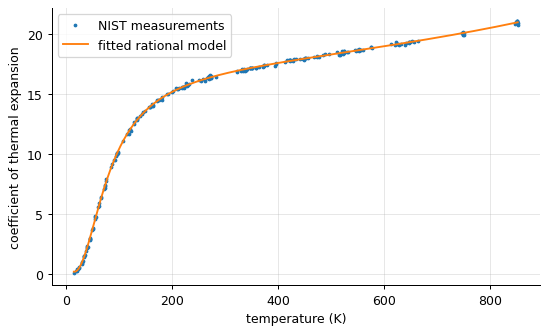

In [2]:
d = np.loadtxt(datasets.path("Hahn1.dat"), skiprows=60)
y, x = d[:, 0], d[:, 1]
def rational(x, b1, b2, b3, b4, b5, b6, b7):
    return (b1 + b2*x + b3*x**2 + b4*x**3) / (1 + b5*x + b6*x**2 + b7*x**3)
start1 = [10, -1, 0.05, -1e-5, -0.05, 0.001, -1e-6]              # NIST start 1 (file header)
fit = fitting.levenberg_marquardt(rational, x, y, start1)
cert = np.array([1.0776351733E+00, -1.2269296921E-01, 4.0863750610E-03, -1.4262662514E-06,
                 -5.7609940901E-03, 2.4053735503E-04, -1.2314450199E-07])   # certified (file header)
print("max relative difference from the certified values:", f"{np.max(np.abs(fit.coef/cert - 1)):.1e}")
print(f"residual SD {fit.sigma:.6f} (certified 8.1803852243E-02)")
xx = np.linspace(x.min(), x.max(), 400)
plt.plot(x, y, ".", ms=4, label="NIST measurements"); plt.plot(xx, rational(xx, *fit.coef), label="fitted rational model")
plt.xlabel("temperature (K)"); plt.ylabel("coefficient of thermal expansion"); plt.legend(); plt.show()

Copper's expansion coefficient rises steeply from near zero at low temperature and levels off above room
temperature - the shape the rational function captures. Starting from NIST's first starting values,
Levenberg-Marquardt reproduces the certified parameters of this "average difficulty" problem. With
seven highly correlated parameters, success depends on reasonable starting values - a good reason why
NIST publishes them.

## Exercise 2

**El Niño.** Read `ENSO.dat` (NIST, real: monthly pressure differences between Easter Island and
   Darwin). Compute its spectrum. Besides the annual cycle, at which periods (in months) are there
   peaks? Compare with the certified periods $b_4$ and $b_7$ in the file header.

Hann window              : strongest peaks at periods [12.0, 42.0, 21.0] months
rectangular, zero-padded : strongest peaks at periods [11.9, 43.6, 27.1] months
certified model: 12 months, b4 = 44.3 months, b7 = 26.9 months;  frequency resolution 1/168 per month


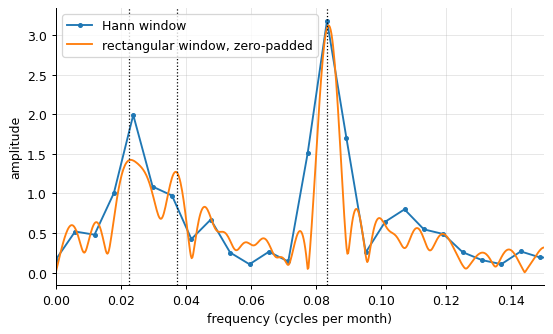

In [3]:
e = np.loadtxt(datasets.path("ENSO.dat"), skiprows=60)
pressure = e[:, 0] - e[:, 0].mean()
f_h, a_h = fourier.spectrum(pressure, fs=1.0)                        # Hann window; 1 sample per month
X = np.fft.rfft(pressure, n=4096)                                   # rectangular window, zero-padded:
f_z, a_z = np.fft.rfftfreq(4096), 2*np.abs(X)/pressure.size         # the spectrum on a much finer grid
def peaks(f, a, longest=80, shortest=10):
    idx = [i for i in range(1, len(a) - 1) if a[i] > a[i-1] and a[i] > a[i+1] and 1/longest < f[i] < 1/shortest]
    return sorted(idx, key=lambda i: -a[i])[:3]
for name, f, a in (("Hann window", f_h, a_h), ("rectangular, zero-padded", f_z, a_z)):
    print(f"{name:<25}: strongest peaks at periods {[round(float(1/f[i]), 1) for i in peaks(f, a)]} months")
print("certified model: 12 months, b4 = 44.3 months, b7 = 26.9 months;  frequency resolution 1/168 per month")
plt.plot(f_h, a_h, "o-", ms=3, label="Hann window")
plt.plot(f_z, a_z, label="rectangular window, zero-padded")
for period in (44.3, 26.9, 12.0):
    plt.axvline(1/period, color="k", ls=":", lw=1)
plt.xlim(0, 0.15); plt.xlabel("frequency (cycles per month)"); plt.ylabel("amplitude"); plt.legend(); plt.show()

The annual cycle (12 months) is the strongest feature. The two El Niño cycles, which NIST's certified model
places at 44.3 and 26.9 months, are only a few frequency bins apart in a 168-month record. With the
**Hann window** - whose wider main lobe suppresses leakage but blurs detail - the 27-month cycle merges into
a shoulder of the 44-month peak and does not appear as a separate maximum. With the **rectangular window**
(sharper main lobe, more leakage) and zero-padding to locate the maxima between bins, both cycles appear
as separate peaks close to the certified periods. Leakage versus resolution is a real trade-off, and on a
short record it decides what you can see; spurious small peaks from noise also appear, so interpret a
spectrum together with physical knowledge. The spectrum finds the cycles and provides starting values; the
nonlinear fit (as in the validation of this dataset) then determines them precisely.

## Exercise 3

Extrapolate the CO₂ trend to find when the trend first exceeds 450 ppm. Refit using only data up to
   2000 and extrapolate again: how far off would that forecast have been for 2026? What does this say
   about extrapolating fitted trends?

In [4]:
cols = ["date", "decimal_year", "co2_ppm", "deseasonalised_ppm", "days", "sd_days", "unc_mean"]
co2 = pd.read_csv(datasets.path("co2_mauna_loa_monthly.csv"), header=0, names=cols)
t, c = co2.decimal_year.to_numpy(), co2.co2_ppm.to_numpy()
def design(t):
    tau = (t - 1990)/10
    return np.column_stack([np.ones_like(t), tau, tau**2] + [f(2*np.pi*k*t) for k in (1, 2) for f in (np.sin, np.cos)])
def trend_450(mask):
    coef = fitting.linear_lstsq(design(t[mask]), c[mask]).coef
    years = np.linspace(1958, 2100, 14201)
    trend = design(years)[:, :3] @ coef[:3]
    return years[np.argmax(trend >= 450)], design(np.array([2026.0]))[:, :3] @ coef[:3], coef
y_all, _, _ = trend_450(np.ones_like(t, bool))
y_2000, pred_2026, _ = trend_450(t < 2000)
actual_2026 = co2.deseasonalised_ppm[co2.decimal_year > 2026].mean()
print(f"trend fitted to all data reaches 450 ppm in {y_all:.1f}")
print(f"trend fitted to 1958-1999 reaches 450 ppm in {y_2000:.1f}")
print(f"forecast for 2026 from the pre-2000 fit: {pred_2026[0]:.1f} ppm; observed (de-seasonalised, 2026): {actual_2026:.1f} ppm")

trend fitted to all data reaches 450 ppm in 2034.4
trend fitted to 1958-1999 reaches 450 ppm in 2035.2
forecast for 2026 from the pre-2000 fit: 426.0 ppm; observed (de-seasonalised, 2026): 428.7 ppm


The fit to all data puts the 450 ppm crossing in the mid-2030s. The forecast made from data up to 2000
undershoots the 2026 level by almost 3 ppm, because the growth rate kept increasing faster than the
pre-2000 quadratic implied. Extrapolated trends carry the assumptions of their functional form
into the future, and their error grows with the extrapolation distance: treat them as scenarios, not
predictions - and state the uncertainty.

## Exercise 4

**Implement it yourself:** write `read_nist(name)` that returns the data, the certified values and their standard deviations for any NIST StRD file, by finding the line that starts with `Data:` and the lines containing `b1 =`, `b2 =`, ... instead of hard-coding `skiprows=60`. Test it on all three NIST files.

In [5]:
def read_nist(name):
    lines = open(datasets.path(name), encoding="utf-8").read().splitlines()
    # "Data:" occurs twice: in the description block and as the marker of the data section - take the LAST
    start = max(i for i, line in enumerate(lines) if line.strip().startswith("Data:"))
    data = np.array([[float(v) for v in line.split()] for line in lines[start + 1:] if line.strip()])
    cert, sd = [], []
    for line in lines[:start]:
        parts = line.split()
        if len(parts) >= 6 and parts[0].startswith("b") and parts[1] == "=":
            cert.append(float(parts[4])); sd.append(float(parts[5]))
    return data, np.array(cert), np.array(sd)

for name in ("Chwirut2.dat", "Hahn1.dat", "ENSO.dat"):
    data, cert, sd = read_nist(name)
    same = np.array_equal(data, np.loadtxt(datasets.path(name), skiprows=60))
    print(f"{name:<13}: data {data.shape}, {len(cert)} certified parameters, identical to loadtxt: {same}")

Chwirut2.dat : data (54, 2), 3 certified parameters, identical to loadtxt: True
Hahn1.dat    : data (236, 2), 7 certified parameters, identical to loadtxt: True
ENSO.dat     : data (168, 2), 9 certified parameters, identical to loadtxt: True


The parser finds the data by its `Data:` marker and the certified values by their `b1 = ...` pattern,
instead of trusting a hard-coded line number, so it works for every file in the NIST collection and keeps
working if a header changes length. One trap: the word `Data:` also appears in the description block
("Data: 1 Response ..."), so a first version that took the *first* match failed - the marker of the data
section is the **last** match. Robust file readers look for structure, not for positions, and are tested
on every file they must read.